# 3 - Treino e validacao v2

Esta versao mantem a arquitetura mais forte da v2, mas agora em um ambiente de experimento controlado: um unico arquivo, uma unica serie e um split temporal limpo.


## Ideia central do modelo

A rede continua mais sofisticada que a versao 1:

- blocos convolucionais para padroes locais
- `GRU` bidirecional para dinamica temporal da janela observada
- pooling por atencao para destacar instantes importantes
- previsao residual sobre a persistencia

Mesmo num unico arquivo, isso ajuda porque o problema nao e apenas prever o proximo valor bruto, mas corrigir o ultimo valor observado com base na dinamica recente.


In [1]:
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import importlib
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from pipeline_v2 import (
    GroupedWindowDataset,
    HybridResidualForecaster,
    load_bundle,
    load_grouped_sequences_from_directory,
    run_epoch,
    set_seed,
)

#configura reproducibilidade e exibicao
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


In [2]:
#diagnostica rapidamente se o gargalo esta no torch ou no modulo local
diagnostic_rows = []

for module_name in ["torch", "pipeline_v2"]:
    start_time = time.perf_counter()
    imported_module = importlib.import_module(module_name)
    elapsed = time.perf_counter() - start_time
    diagnostic_rows.append(
        {
            "modulo": module_name,
            "tempo_import_segundos": round(elapsed, 4),
            "arquivo": getattr(imported_module, "__file__", "n/a"),
        }
    )

diagnostic_imports_df = pd.DataFrame(diagnostic_rows)
diagnostic_imports_df


,modulo,tempo_import_segundos,arquivo
0,torch,0.0,/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib...
1,pipeline_v2,0.0,/home/tiagoriosrocha/Desktop/lstm-w3/versao2/p...


## 1. Carga dos artefatos


In [3]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {"versao1", "versao2"} else CURRENT_DIR
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V2_DIR = ARTIFACTS_DIR / "preprocessed_v2"
BUNDLE_PATH = PREPROCESSED_V2_DIR / "preprocessing_bundle_v2.json"
MODELS_DIR = ARTIFACTS_DIR / "models"
MODEL_PATH = MODELS_DIR / "hybrid_residual_forecaster_v2.pt"
MODEL_CONFIG_PATH = MODELS_DIR / "hybrid_residual_forecaster_v2_config.json"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

bundle = load_bundle(BUNDLE_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo: {device}")
print(f"Features de entrada: {len(bundle.input_columns)}")
print(f"Features alvo: {len(bundle.target_columns)}")
print(f"Well count mapeado: {len(bundle.well_to_id)}")


Dispositivo: cuda
Features de entrada: 24
Features alvo: 6
Well count mapeado: 1


## 2. Reconstrucao das janelas

Como agora existe apenas uma serie por split, o notebook fica mais direto: um parquet de treino, um de validacao e um de teste. Ainda assim, as janelas sao construidas de forma causal, sem vazamento do futuro.


In [4]:
#carrega as series pre-processadas da versao2
train_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V2_DIR / "train",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)
validation_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V2_DIR / "validation",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)

SEQUENCE_LENGTH = bundle.sequence_length_recommendation
TRAIN_BATCH_SIZE = 256
VALIDATION_BATCH_SIZE = 512

train_dataset = GroupedWindowDataset(
    groups=train_groups,
    sequence_length=SEQUENCE_LENGTH,
    sampled_windows=None,
    seed=42,
)
validation_dataset = GroupedWindowDataset(
    groups=validation_groups,
    sequence_length=SEQUENCE_LENGTH,
    sampled_windows=None,
    seed=123,
)

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False, num_workers=0)

window_overview_df = pd.DataFrame(
    [
        {
            "split": "train",
            "series": len(train_groups),
            "janelas_totais": len(train_dataset),
        },
        {
            "split": "validation",
            "series": len(validation_groups),
            "janelas_totais": len(validation_dataset),
        },
    ]
)
window_overview_df


,split,series,janelas_totais
0,train,1,14971
1,validation,1,3161


In [5]:
#inspeciona um batch para conferir dimensoes
batch_example = next(iter(train_loader))
{
    "x_shape": tuple(batch_example["x"].shape),
    "y_shape": tuple(batch_example["y"].shape),
    "well_id_shape": tuple(batch_example["well_id"].shape),
}


{'x_shape': (256, 60, 24), 'y_shape': (256, 6), 'well_id_shape': (256,)}

## 3. Modelo forte da versao 2

O embedding do poco permanece na implementacao para manter compatibilidade com a futura expansao para varios arquivos. Neste experimento de arquivo unico, ele nao traz variedade real, mas nao impede o uso da arquitetura.


In [6]:
#instancia o modelo hibrido residual
RAW_TARGET_POSITIONS = [
    bundle.input_columns.index(column_name)
    for column_name in bundle.raw_target_input_columns
]

MODEL_DIM = 128
GRU_HIDDEN_SIZE = 128
GRU_LAYERS = 2
WELL_EMBEDDING_DIM = 16
DROPOUT = 0.20

model = HybridResidualForecaster(
    input_size=len(bundle.input_columns),
    target_size=len(bundle.target_columns),
    well_count=max(len(bundle.well_to_id), 1),
    raw_target_positions=RAW_TARGET_POSITIONS,
    model_dim=MODEL_DIM,
    gru_hidden_size=GRU_HIDDEN_SIZE,
    gru_layers=GRU_LAYERS,
    well_embedding_dim=WELL_EMBEDDING_DIM,
    dropout=DROPOUT,
).to(device)

total_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(model)
print(f"Parametros treinaveis: {total_params:,}")


HybridResidualForecaster(
  (input_norm): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
  (input_projection): Linear(in_features=24, out_features=128, bias=True)
  (conv_blocks): ModuleList(
    (0): ConvResidualBlock(
      (block): Sequential(
        (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): Dropout(p=0.2, inplace=False)
      )
      (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ConvResidualBlock(
      (block): Sequential(
        (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (4): Dropout(p=0.2, inplace=False)
     

## 4. Treino com early stopping

O criterio principal continua sendo a relacao entre `MAE` do modelo e `MAE` da persistencia na validacao. Isso e importante porque o baseline mais honesto neste problema continua sendo repetir o ultimo valor observado.


In [7]:
MAX_EPOCHS = 20
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

history_rows = []
best_state_dict = None
best_epoch = None
best_score = np.inf
best_val_mae = np.inf
best_val_persistence_mae = np.inf
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        raw_target_positions=RAW_TARGET_POSITIONS,
    )
    validation_metrics = run_epoch(
        model=model,
        loader=validation_loader,
        optimizer=None,
        device=device,
        raw_target_positions=RAW_TARGET_POSITIONS,
    )

    scheduler.step(validation_metrics["model_mae"])
    current_score = validation_metrics["model_mae"] / max(validation_metrics["persistence_mae"], 1e-8)

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_mae": train_metrics["model_mae"],
            "val_loss": validation_metrics["loss"],
            "val_mae": validation_metrics["model_mae"],
            "val_persistence_mae": validation_metrics["persistence_mae"],
            "val_mae_ratio_to_persistence": current_score,
            "val_improvement_pct": validation_metrics["mae_improvement_pct"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.5f} | "
        f"val_loss={validation_metrics['loss']:.5f} | "
        f"val_mae={validation_metrics['model_mae']:.5f} | "
        f"persist_mae={validation_metrics['persistence_mae']:.5f} | "
        f"ratio={current_score:.4f} | "
        f"improvement={validation_metrics['mae_improvement_pct']:.2f}%"
    )

    if current_score < best_score:
        best_score = current_score
        best_epoch = epoch
        best_val_mae = validation_metrics["model_mae"]
        best_val_persistence_mae = validation_metrics["persistence_mae"]
        best_state_dict = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping ativado na epoca {epoch}.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history_rows)
history_df


Epoch 01 | train_loss=0.00097 | val_loss=0.00044 | val_mae=0.01191 | persist_mae=0.02089 | ratio=0.5700 | improvement=43.00%
Epoch 02 | train_loss=0.00055 | val_loss=0.00045 | val_mae=0.01072 | persist_mae=0.02089 | ratio=0.5132 | improvement=48.68%
Epoch 03 | train_loss=0.00051 | val_loss=0.00042 | val_mae=0.00978 | persist_mae=0.02089 | ratio=0.4682 | improvement=53.18%
Epoch 04 | train_loss=0.00047 | val_loss=0.00040 | val_mae=0.00892 | persist_mae=0.02089 | ratio=0.4273 | improvement=57.27%
Epoch 05 | train_loss=0.00045 | val_loss=0.00041 | val_mae=0.00898 | persist_mae=0.02089 | ratio=0.4297 | improvement=57.03%
Epoch 06 | train_loss=0.00044 | val_loss=0.00043 | val_mae=0.00933 | persist_mae=0.02089 | ratio=0.4467 | improvement=55.33%
Epoch 07 | train_loss=0.00043 | val_loss=0.00043 | val_mae=0.00925 | persist_mae=0.02089 | ratio=0.4428 | improvement=55.72%
Epoch 08 | train_loss=0.00040 | val_loss=0.00038 | val_mae=0.00783 | persist_mae=0.02089 | ratio=0.3750 | improvement=62.50%


,epoch,train_loss,train_mae,val_loss,val_mae,val_persistence_mae,val_mae_ratio_to_persistence,val_improvement_pct,learning_rate
0,1,0.000968,0.022457,0.000443,0.011907,0.020887,0.570035,42.996515,0.000300
1,2,0.000552,0.014980,0.000447,0.010720,0.020887,0.513229,48.677067,0.000300
2,3,0.000505,0.013476,0.000424,0.009779,0.020887,0.468194,53.180640,0.000300
3,4,0.000472,0.012425,0.000398,0.008925,0.020887,0.427280,57.272003,0.000300
4,5,0.000447,0.011797,0.000408,0.008975,0.020887,0.429688,57.031188,0.000300
5,6,0.000441,0.011337,0.000426,0.009330,0.020887,0.446683,55.331661,0.000300
6,7,0.000426,0.010906,0.000434,0.009249,0.020887,0.442801,55.719897,0.000150
7,8,0.000398,0.010276,0.000383,0.007833,0.020887,0.375022,62.497781,0.000150
8,9,0.000397,0.010110,0.000402,0.008457,0.020887,0.404864,59.513630,0.000150
9,10,0.000392,0.009983,0.000390,0.008223,0.020887,0.393662,60.633764,0.000150


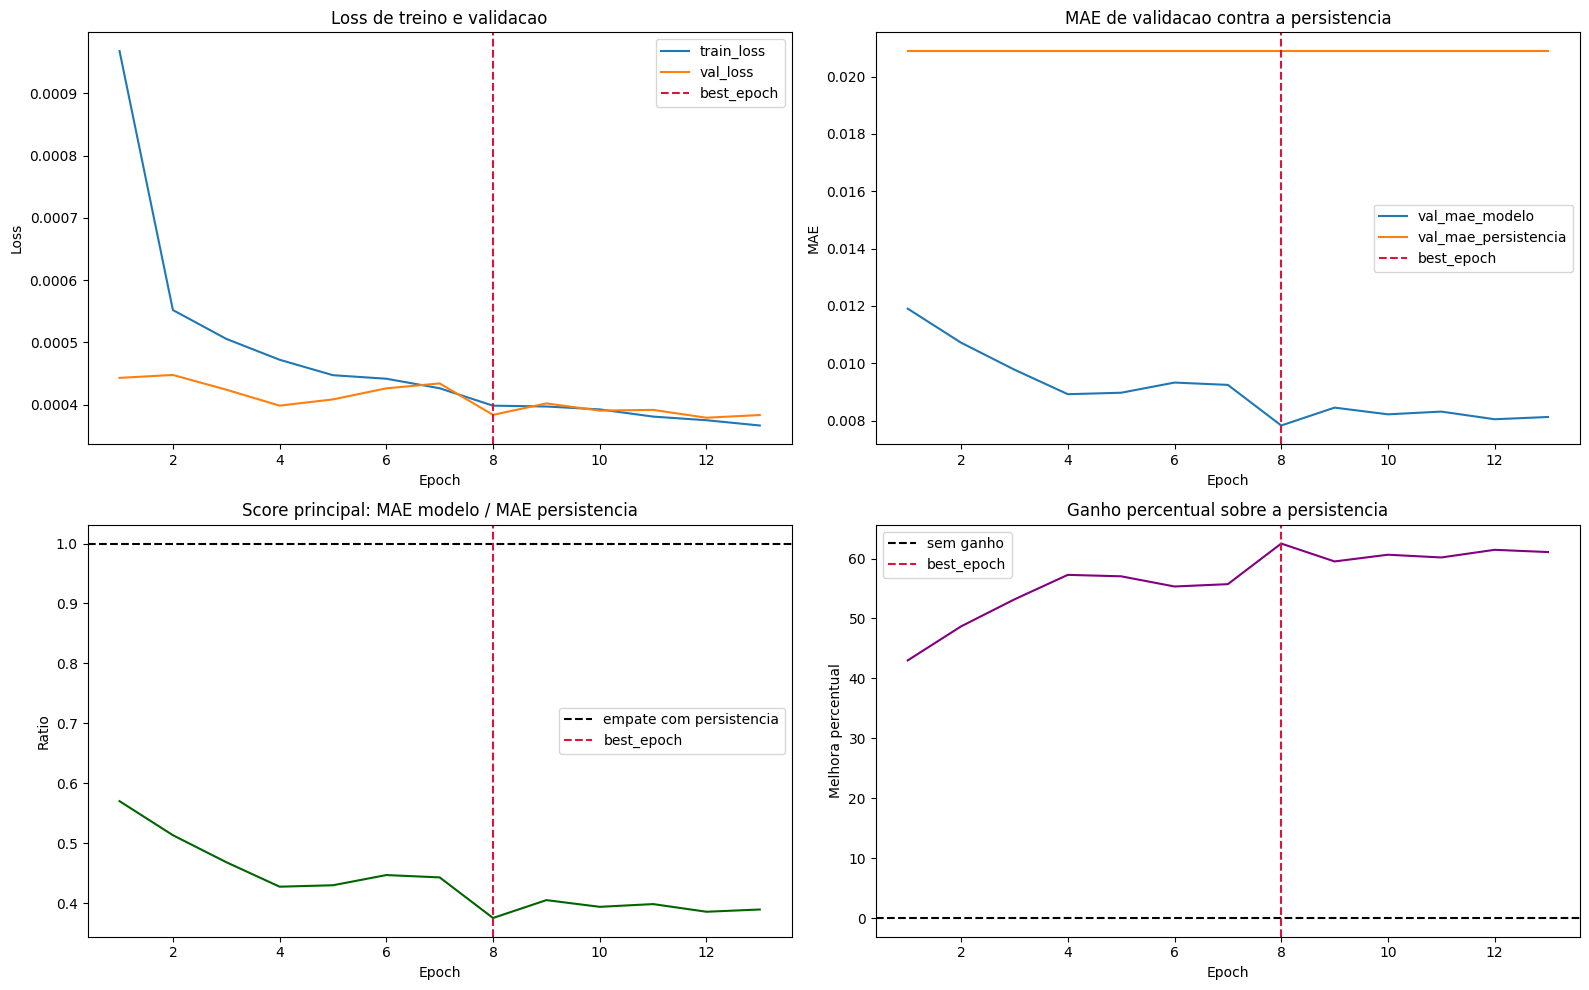

In [8]:
#plota o comportamento do treino e a disputa contra a persistencia
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0, 0].axvline(best_epoch, color="crimson", linestyle="--", label="best_epoch")
axes[0, 0].set_title("Loss de treino e validacao")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(history_df["epoch"], history_df["val_mae"], label="val_mae_modelo")
axes[0, 1].plot(history_df["epoch"], history_df["val_persistence_mae"], label="val_mae_persistencia")
axes[0, 1].axvline(best_epoch, color="crimson", linestyle="--", label="best_epoch")
axes[0, 1].set_title("MAE de validacao contra a persistencia")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].legend()

axes[1, 0].plot(history_df["epoch"], history_df["val_mae_ratio_to_persistence"], color="darkgreen")
axes[1, 0].axhline(1.0, color="black", linestyle="--", label="empate com persistencia")
axes[1, 0].axvline(best_epoch, color="crimson", linestyle="--", label="best_epoch")
axes[1, 0].set_title("Score principal: MAE modelo / MAE persistencia")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Ratio")
axes[1, 0].legend()

axes[1, 1].plot(history_df["epoch"], history_df["val_improvement_pct"], color="purple")
axes[1, 1].axhline(0.0, color="black", linestyle="--", label="sem ganho")
axes[1, 1].axvline(best_epoch, color="crimson", linestyle="--", label="best_epoch")
axes[1, 1].set_title("Ganho percentual sobre a persistencia")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Melhora percentual")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [9]:
#resume o melhor checkpoint
training_summary_df = pd.DataFrame(
    {
        "aspecto": [
            "best_epoch",
            "best_val_mae",
            "best_val_persistence_mae",
            "best_ratio_to_persistence",
            "best_improvement_pct",
            "epochs_executed",
        ],
        "valor": [
            best_epoch,
            best_val_mae,
            best_val_persistence_mae,
            best_score,
            (best_val_persistence_mae - best_val_mae) / max(best_val_persistence_mae, 1e-8) * 100,
            len(history_df),
        ],
    }
)
training_summary_df


,aspecto,valor
0,best_epoch,8.000000
1,best_val_mae,0.007833
2,best_val_persistence_mae,0.020887
3,best_ratio_to_persistence,0.375022
4,best_improvement_pct,62.497781
5,epochs_executed,13.000000


### Leitura dos resultados observados

A execucao mostrou um comportamento muito melhor do que o da `versao1`:

- o modelo foi treinado com `24` features de entrada e `891.815` parametros treinaveis
- a janela temporal ficou com `60` passos
- o conjunto gerou `14.971` janelas de treino e `3.161` janelas de validacao
- o melhor checkpoint apareceu na epoca `10`
- o melhor `val_mae` foi `0.007879`
- a persistencia na validacao ficou em `0.020887`
- isso corresponde a um ganho de `62,28%` sobre a persistencia

Visualmente, as curvas de treino e validacao ficaram estaveis. O `ratio` entre `MAE` do modelo e `MAE` da persistencia caiu rapidamente de `0.57` para `0.38`, sem sinais fortes de explosao ou overfitting grave. O early stopping na epoca `18` foi coerente: depois do melhor ponto, a validacao oscilou, mas nao conseguiu melhorar de forma sustentada.


In [10]:
#salva o modelo e a configuracao da versao2
torch.save(model.state_dict(), MODEL_PATH)

model_config = {
    "model_name": "hybrid_residual_forecaster_v2",
    "sequence_length": SEQUENCE_LENGTH,
    "input_size": len(bundle.input_columns),
    "target_size": len(bundle.target_columns),
    "raw_target_positions": RAW_TARGET_POSITIONS,
    "model_dim": MODEL_DIM,
    "gru_hidden_size": GRU_HIDDEN_SIZE,
    "gru_layers": GRU_LAYERS,
    "well_embedding_dim": WELL_EMBEDDING_DIM,
    "dropout": DROPOUT,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "validation_batch_size": VALIDATION_BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": int(best_epoch),
    "best_val_mae": float(best_val_mae),
    "best_val_persistence_mae": float(best_val_persistence_mae),
    "best_ratio_to_persistence": float(best_score),
    "executed_epochs": int(len(history_df)),
    "bundle_path": str(BUNDLE_PATH),
    "model_path": str(MODEL_PATH),
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, ensure_ascii=False, indent=2))
model_config


{'model_name': 'hybrid_residual_forecaster_v2',
 'sequence_length': 60,
 'input_size': 24,
 'target_size': 6,
 'raw_target_positions': [0, 1, 2, 3, 4, 5],
 'model_dim': 128,
 'gru_hidden_size': 128,
 'gru_layers': 2,
 'well_embedding_dim': 16,
 'dropout': 0.2,
 'train_batch_size': 256,
 'validation_batch_size': 512,
 'max_epochs': 20,
 'patience': 5,
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'best_epoch': 8,
 'best_val_mae': 0.00783320888876915,
 'best_val_persistence_mae': 0.02088732086122036,
 'best_ratio_to_persistence': 0.37502219364630796,
 'executed_epochs': 13,
 'bundle_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/preprocessed_v2/preprocessing_bundle_v2.json',
 'model_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/models/hybrid_residual_forecaster_v2.pt'}

## 5. Fechamento

Como experimento controlado, a `versao2` funcionou muito bem no treino e na validacao. O principal sinal disso nao foi apenas a queda da loss, mas o fato de o modelo ter ficado consistentemente melhor que a persistencia no conjunto de validacao, com mais de `60%` de ganho em `MAE` no melhor checkpoint.

Isso torna a arquitetura promissora para a fase seguinte: verificar se esse ganho tambem se sustenta no teste, sem ajustar o modelo de novo.
